# Pixel Operations with OpenCV and Numpy

#[author]
#CS4330 Computer Vision
#Lab 1


In [5]:
# one-time prep work
import numpy as np
import matplotlib.cbook as cbook
import matplotlib.pyplot as plt
# set matplotlib to render in this window, with the specified figure size
%matplotlib inline
import pylab
pylab.rcParams['figure.figsize'] = (12.0, 4.0)
import cv2
print("OpenCV Version: ", cv2.__version__)
import urllib.request

url = "https://nps.edu/o/npsdxp-theme/images/company_logo.png"
res = urllib.request.urlretrieve(url, 'nps_logo.png')

OpenCV Version:  4.10.0


## Troubleshooting Python imports and conda

Python version: 3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:05:38) [MSC v.1929 64 bit (AMD64)]
Library paths:
c:\Users\jgooh\anaconda3\envs\cs4330\python312.zip
c:\Users\jgooh\anaconda3\envs\cs4330\DLLs
c:\Users\jgooh\anaconda3\envs\cs4330\Lib
c:\Users\jgooh\anaconda3\envs\cs4330

c:\Users\jgooh\anaconda3\envs\cs4330\Lib\site-packages
c:\Users\jgooh\anaconda3\envs\cs4330\Lib\site-packages\win32
c:\Users\jgooh\anaconda3\envs\cs4330\Lib\site-packages\win32\lib
c:\Users\jgooh\anaconda3\envs\cs4330\Lib\site-packages\Pythonwin


'which' is not recognized as an internal or external command,
operable program or batch file.



     active environment : cs4330
    active env location : C:\Users\jgooh\anaconda3\envs\cs4330
            shell level : 2
       user config file : C:\Users\jgooh\.condarc
 populated config files : C:\Users\jgooh\anaconda3\.condarc
                          C:\Users\jgooh\.condarc
          conda version : 25.11.0
    conda-build version : 25.11.1
         python version : 3.13.9.final.0
                 solver : libmamba (default)
       virtual packages : __archspec=1=x86_64_v4
                          __conda=25.11.0=0
                          __cuda=0=0
                          __win=10.0.26200=0
       base environment : C:\Users\jgooh\anaconda3  (writable)
      conda av data dir : C:\Users\jgooh\anaconda3\etc\conda
  conda av metadata url : None
           channel URLs : https://repo.anaconda.com/pkgs/main/win-64
                          https://repo.anaconda.com/pkgs/main/noarch
                          https://repo.anaconda.com/pkgs/r/win-64
                          h

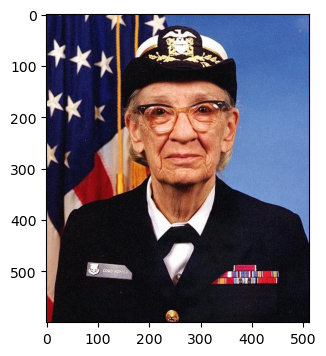

In [6]:
!which python
import sys
print("Python version:", sys.version)
print("Library paths:")
for path in sys.path:
    print(path)
import os
!conda info
print ("---> Active environment :", os.environ['CONDA_DEFAULT_ENV'], "  prefix: ", os.environ["CONDA_PREFIX"])

import cv2
print(f"Library path for cv2:", cv2.__file__)
print("OpenCV Version: ", cv2.__version__)
imgpath = cbook.get_sample_data('grace_hopper.jpg',asfileobj=False)
img = cv2.imread(imgpath)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

## Part 1: Learn about image formats
Run the following code and then answer the questions below. Feel free to replace the `nps_logo.png` image file with one of your choosing. Put it into the "notebooks" folder on your host computer. Look up function documentations at the [OpenCV Documentation](http://docs.opencv.org/), paying attention to the installed version, and keep this close at hand. (If you are using the Docker container, currently the OpenCV documentation for the version that's installed on the Docker container is the [OpenCV 3.1.0 Documentation](http://docs.opencv.org/3.1.0).)

image data:  <class 'numpy.ndarray'> uint8
before resizing:  (93, 135, 3)
after resizing:  (46, 27, 3)
grayscale:  (46, 27)


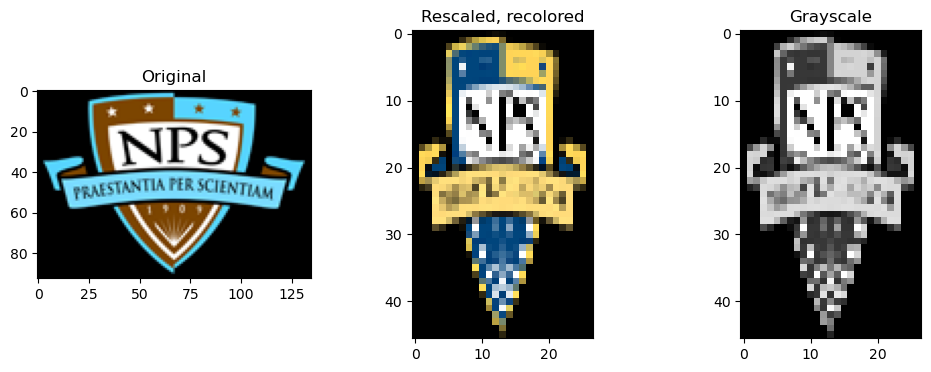

In [7]:
img = cv2.imread('nps_logo.png')
print("image data: ", type(img), img.dtype)

plt.subplot(131)
plt.imshow(img)
plt.title('Original')
print("before resizing: ", img.shape)

img = cv2.resize(img, None, fx=0.2, fy=0.5)
print("after resizing: ", img.shape)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
print("grayscale: ", gray.shape)

plt.subplot(132)
plt.imshow(img)
plt.title('Rescaled, recolored')

plt.subplot(133)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale')

plt.show()

### Questions
1. What is the output of "image data:..." and what does each of the two values mean?
<class 'numpy.ndarray'> uint8, where numpy.ndarray is the data type, which is a NumPy array, looking like how OpenCV stores read images from it's imread function. uint8 is the data type of the pixel values.

1. Read up about the [numpy.ndarray](http://docs.scipy.org/doc/numpy/reference/arrays.ndarray.html). How can you select one of the channels of the image?

In OpenCV, the order is BGR not RGB for the channels. In this case, this means you are accessing a 3-depth tensor, where blue = [:,:,0], green = [:,:,1], and red = [:,:,2]. 

1. How can you crop a rectangular area from the image?

You take portions of the image via array slicing in the form of img[y1:y2, x1:x2]

1. In `cv2.resize`, which dimension does fx refer to? And fy?
fx is the scale factor for width and fy is the scale factor for height

1. How can you deterime from the contents of the `img` variable whether the channels are ordered RGB or BGR?

I could use the RGB2BGR method and see if the rendered image' the same or different.

1. Which dimension does `img.shape[0]` refer to? `img.shape[1]`? `img.shape[2]`?

height (rows), width (columns), channels (3 for bgr/rgb, 1 for grayscale)

1. How are the arguments to the `subplot` method to be interpreted? 131, 132, and 133?

subplot(nrows, ncols, index, **kwargs) is from the documentation for the arguments of the method.
A 3-digit integer. The digits are interpreted as if given separately as three single-digit integers, i.e. fig.add_subplot(235) is the same as fig.add_subplot(2, 3, 5)."
-131: 1 row, 3 columns, first index
-132: 1 row, 3 columns, second index
-133: 1 row, 3 columns, third index 

1. What effect does `cmap='gray'` have? If you leave it out, why does the grayscale image show up with colors?

Colormap instances are used to convert data values (floats) from the interval [0, 1] to the RGBA color that the respective Colormap represents. 
cmap='gray tells marplotlib to use a grayscale color  map (made of black and white)

(46, 27)

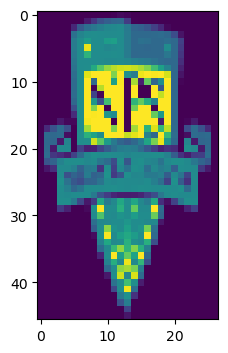

In [8]:
blue = img[:, :, 0]      #all pixels, blue channel
green = img[:, :, 1]     #all pixels, green channel
red = img[:, :, 2]       #all pixels, red channel
plt.imshow(red)
red.shape

## Part 2: Experiment with Pixels
Edit each of the code snippets according to the instructions.


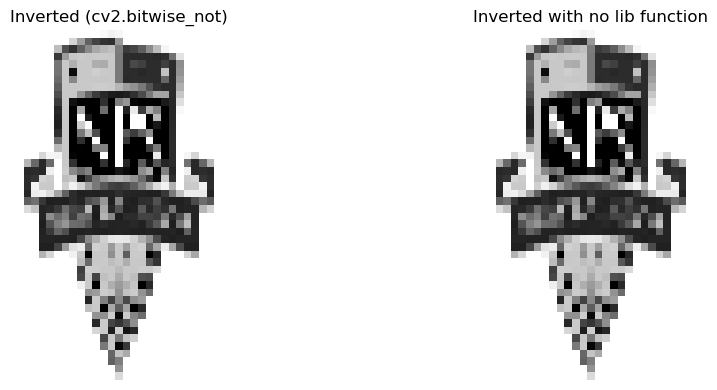

In [12]:
# Invert the image: dark becomes light, light becomes dark
out = gray.copy()
for row in range(gray.shape[0]):
    for col in range(gray.shape[1]):
        out[row, col] = 255 - gray[row, col]


inv_lib = cv2.bitwise_not(gray)
plt.subplot(1,2,1)
plt.imshow(inv_lib, cmap='gray')
plt.title("Inverted (cv2.bitwise_not)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(out, cmap='gray')
plt.title("Inverted with no lib function")
plt.axis("off")

plt.tight_layout()
plt.show()

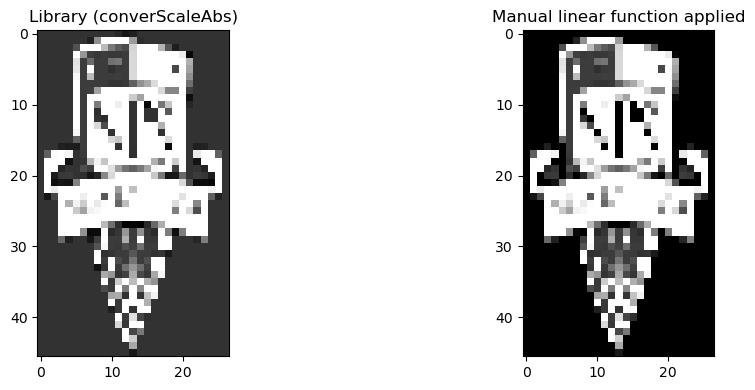

In [19]:
# Apply the following linear function to the pixel values: 
#this means ax+b is applied to each pixel independently, where a controls the contrast and b controls the brightness (by shifting all values up or down)
#so mutiplying a scales the histogram -> changes contrast
#adding/sub bv shifts histogram left/eright changing brightness
# y = 2x-50. 
# Also, what happens with pixel values outside the uint8 range?
out = gray.copy()
for row in range(gray.shape[0]):
    for col in range(gray.shape[1]):
        val = 2*int(gray[row,col])-50 #compute it in ints

        if val <0:
            val = 0
        if val > 255:
            val = 255
        out[row,col] = val
         
out2 = cv2.convertScaleAbs(gray,alpha=2,beta=-50)

plt.subplot(1,2,1)
plt.imshow(out2,cmap='gray')
plt.title("Library (converScaleAbs)")

plt.subplot(1,2,2)
plt.imshow(out,cmap='gray')
plt.title("Manual linear function applied")

plt.tight_layout()
plt.show()

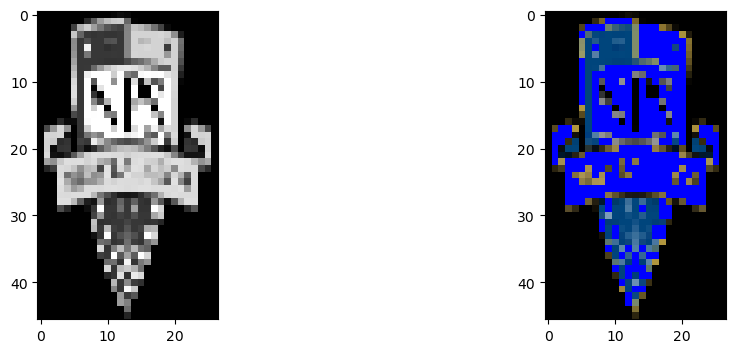

In [16]:
# Based on the value of the grayscale image pixel, modify the respective pixel in the color image: 
# If the grayscale value is above a threshold, make the color pixel blue. 
thresh = 150 #arbitrary
trip_blue = gray > thresh
# Subplot the color image next to the grayscale image.

out = img.copy()
h,w = gray.shape
for row in range(h):
    for col in range(w):
        if gray[row,col]>thresh:
            out[row,col] = 0,0,255 #convert to blue for given pixel

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')

plt.subplot(1,2,2)
plt.imshow(out)



## Part 3: Experiment with Thresholding
Select a more natural image from your computer or the web, that is, an image that is not a logo. Read it in, convert it to grayscale (be careful not to confuse a RGB image with a BGR image), and experiment with various thresholding functions. The only new function you will have to learn about is the `threshold` function itself. Take a look at the [OpenCV thresholding documentation](http://docs.opencv.org/3.1.0/d7/d4d/tutorial_py_thresholding.html#gsc.tab=0) to learn about the different methods available to you. Once you are satisfied with your thresholding result, load several *different* images and try the *same thresholding method and parameters* on them. Are you still satisfied?

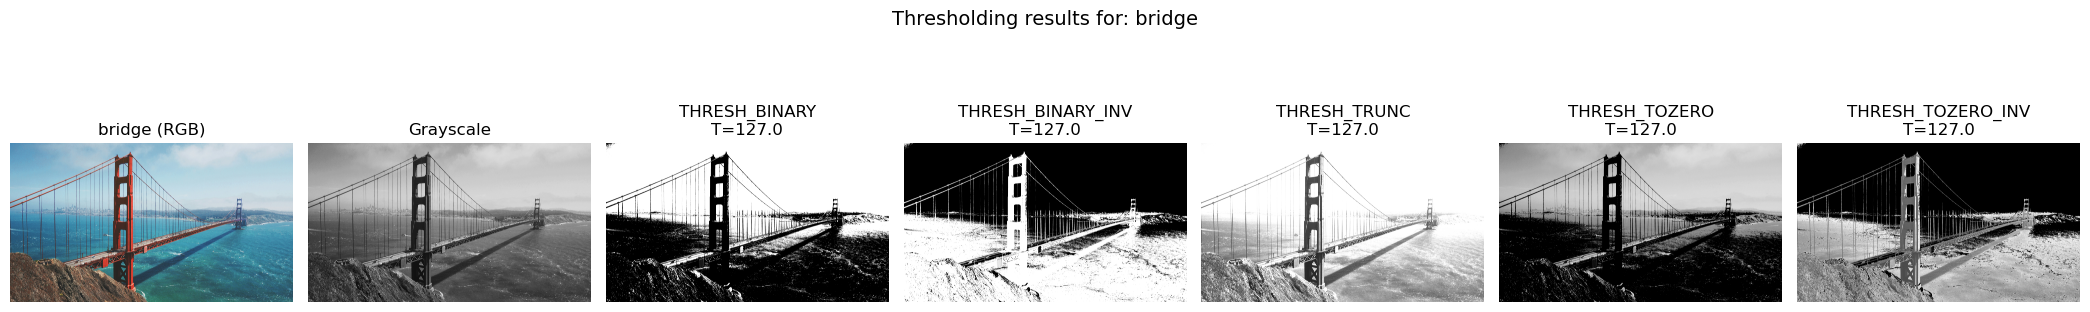

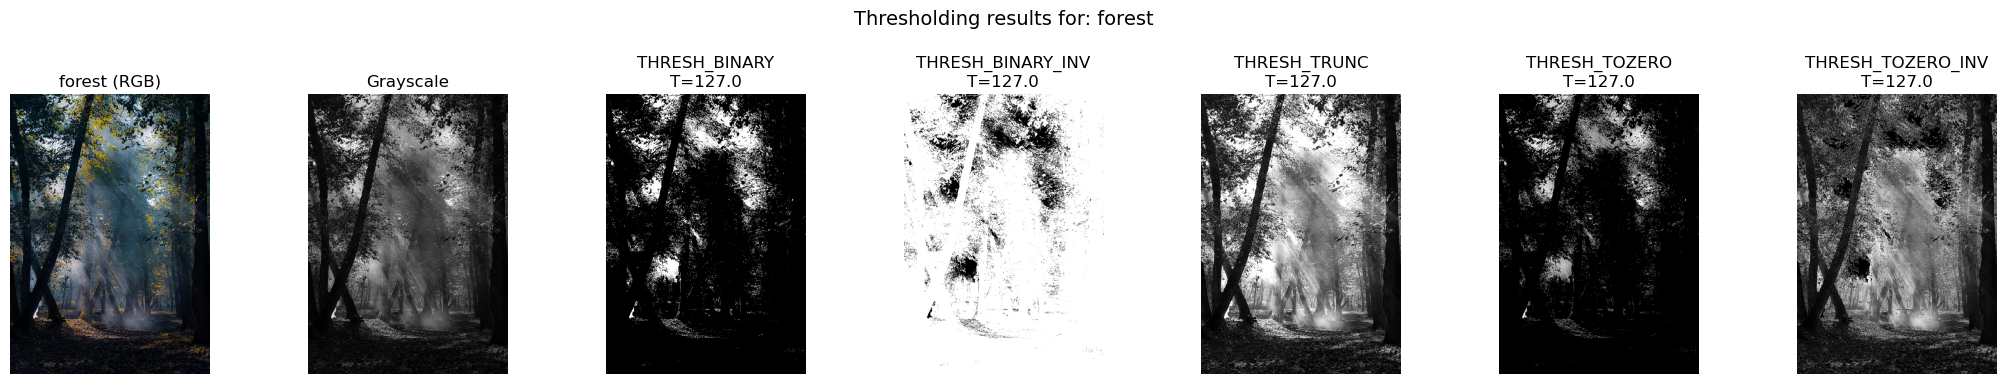

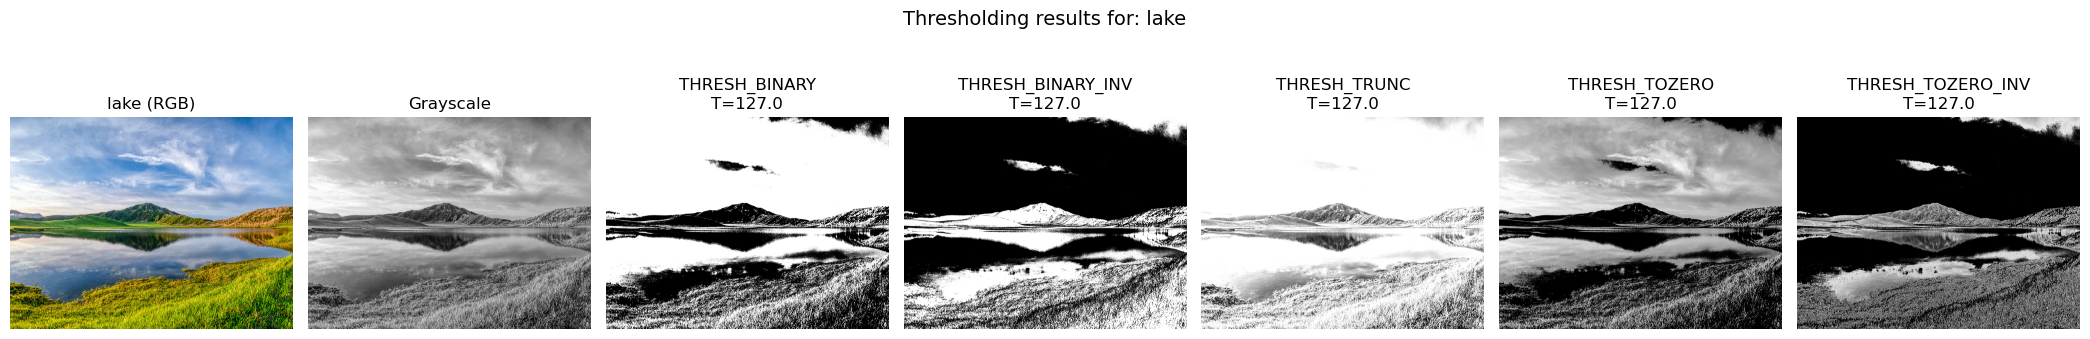

In [ ]:
'''Here, the matter is straight forward.
If pixel value is greater than a threshold value, it is assigned one value (may be white), 
else it is assigned another value (may be black). 
The function used is cv2.threshold. First argument is the source image, which should be a grayscale image.
Second argument is the threshold value which is used to classify the pixel values.
Third argument is the maxVal which represents the value to be given if pixel value is more
than (sometimes less than) the threshold value. 
OpenCV provides different styles of thresholding and it is decided by the fourth parameter of the function. Different types are:

cv2.THRESH_BINARY
cv2.THRESH_BINARY_INV
cv2.THRESH_TRUNC
cv2.THRESH_TOZERO
cv2.THRESH_TOZERO_INV'''

files = {
    'bridge': 'gg_bridge.jpg',
    'forest': 'trees_forest.jpg',
    'lake': 'lake_reflection.jpg'
}

# threshold settings
T = 127
MAXVAL = 255

# simple threshold flags and labels
flags = [
    (cv2.THRESH_BINARY, 'THRESH_BINARY'),
    (cv2.THRESH_BINARY_INV, 'THRESH_BINARY_INV'),
    (cv2.THRESH_TRUNC, 'THRESH_TRUNC'),
    (cv2.THRESH_TOZERO, 'THRESH_TOZERO'),
    (cv2.THRESH_TOZERO_INV, 'THRESH_TOZERO_INV')
]

for name, fname in files.items():
    bgr = cv2.imread(fname)
    if bgr is None:
        print(f"Could not read {fname}")
        continue

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)            #to be safe just convert all to rgb
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)         #for thresholding

    ncols = 2 + len(flags)   #original, gray, then each threshold result
    plt.figure(figsize=(3*ncols, 4))

    #show original and grayscale
    plt.subplot(1, ncols, 1); plt.imshow(rgb); plt.title(f'{name} (RGB)'); plt.axis('off')
    plt.subplot(1, ncols, 2); plt.imshow(gray, cmap='gray'); plt.title('Grayscale'); plt.axis('off')

    #apply each simple threshold and show
    for i, (flag, label) in enumerate(flags, start=3):
        ret, out = cv2.threshold(gray, T, MAXVAL, flag)
        plt.subplot(1, ncols, i); plt.imshow(out, cmap='gray')
        plt.title(f'{label}\nT={ret if ret!=0 else T}'); plt.axis('off')

    plt.suptitle(f'Thresholding results for: {name}', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


Among the tested methods, THRESH_BINARY and THRESH_TOZERO produced the most visually meaningful results relative to the grayscale images. THRESH_BINARY was effective at separating bright structures from darker backgrounds when the grayscale image had good contrast, but it removed all intensity variation by forcing pixels to pure black or white. THRESH_TOZERO preserved the original grayscale values for pixels above the threshold while suppressing darker regions, which retained more texture and shading information. THRESH_TOZERO often appeared more robust across different images, especially when lighting and contrast varied. So, yes, I am satisfied with the result based on the few images I tested.

## Part 4: Application Example: Rosetta Space Mission
See this [LA Times Story](http://www.latimes.com/science/sciencenow/la-sci-sn-goosebumps-rosetta-science-20150121-story.html) or the [Rosetta story](https://www.mps.mpg.de/Rosetta-unravels-formation-of-sunrise-jets) and then the [Rosetta 3D model](https://sci.esa.int/comet-viewer/) where you can click on the "Seth" region and then identify the central black crater from which the image below is taken.

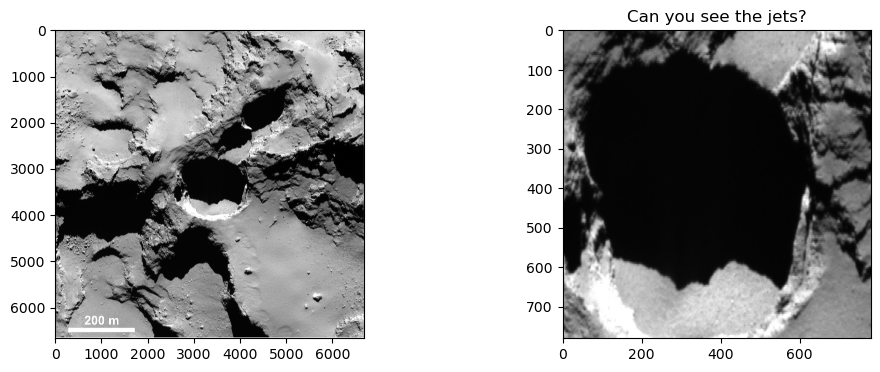

In [34]:
url = 'http://www.esa.int/var/esa/storage/images/esa_multimedia/images/2015/01/active_pit_in_the_seth_region/15206750-1-eng-GB/Active_pit_in_the_Seth_region.jpg';
res = urllib.request.urlretrieve(url, 'seth_pit.jpg')
img = cv2.imread('seth_pit.jpg')
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray') #convert to grayscale

new_height = 780  # for example, 300 pixels
ratio = new_height / img.shape[0]
new_width = int(img.shape[1] * ratio)

# display the raw image, cropped
# look at the image - can you see the jets?
crop = img[2643:4000,2607:4537]
res = cv2.resize(crop,(new_width, new_height)) #takes src image which is the cropped image, with new width and new height
plt.subplot(1,2,2)
plt.title('Can you see the jets?') #no
plt.imshow(res, cmap='gray')
plt.show()

Your task is to "enhance" the dark region in the image such that the very faint "jets" of gas become visible. I recommend looking at some pixel values to get an idea for storage and value ranges. Then modify the intensities with simple pixel operations. Finally, use a mask to create a "composite" image where only the dark areas are enhanced and the gray and brighter areas are left unchanged.

5
gray min/max/mean: 0 255 73.32503365179421
10/50/90 percentiles: 5.0 25.0 198.0
dark threshold of the 10th percentile: 5


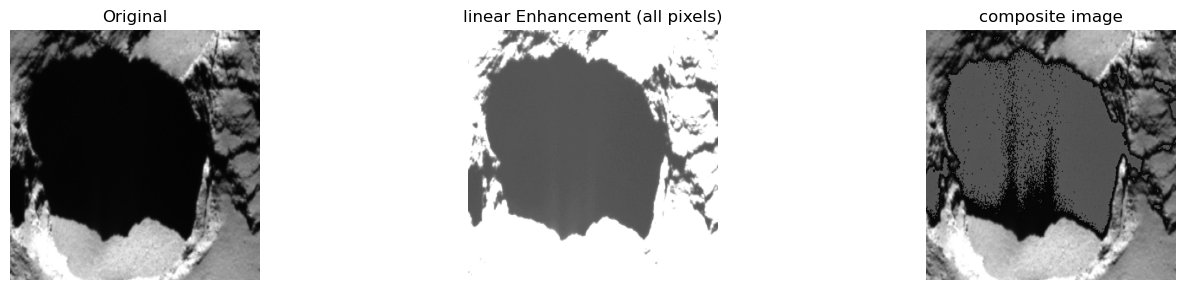

  Original RGB: [5 5 5]
  Composite RGB: [85 85 85]
  Enhanced RGB: [85 85 85]


In [49]:
#first, determine what format the image has.
working_copy = res.copy()
gray_working_copy = cv2.cvtColor(working_copy, cv2.COLOR_BGR2GRAY)

#opencv images are numpy arrays. we can index to look it in a height x width format
print(gray_working_copy[400,400])
#referencing the image above and looking at the axes, we can see a return value of that pixel of 5, 
#which is very gray nearly black on the 0-255 scale

#Inspect the image to learn value ranges and percentiles.
print("gray min/max/mean:", gray_working_copy.min(), gray_working_copy.max(), gray_working_copy.mean())
print("10/50/90 percentiles:", np.percentile(gray_working_copy,10), np.percentile(gray_working_copy,50), np.percentile(gray_working_copy,90))

#we can use linear scaling to adjust the contrast and brightness like in the above example, for alpha and beta respectively
lin_alpha = 3 
lin_beta = 70 #add brightness 
lin_enhanced = cv2.convertScaleAbs(working_copy, alpha=lin_alpha, beta=lin_beta)

'''
Choose a threshold for "dark" pixels (use percentiles rather than a fixed 0–255 number).
Enhance dark pixels with a simple point operation (linear scale or gamma).
Mask & composite: replace only dark pixels in the original image with the enhanced values.
Verify visually and by checking pixel values before/after.
'''

#Choose threshold at 10th percentile - darkest 10% of pixels from the grayscale image
thresh = int(np.percentile(gray_working_copy,10))
print(f"dark threshold of the 10th percentile: {thresh}")

#make a mask of dark pixels (bool vals)
#This creates a boolean array where True = pixel is dark (<=threshold), False = pixel is bright
dark_mask = (gray_working_copy <= thresh)

#Convert images from BGR (OpenCV format) to RGB (matplotlib format) for display
orig_rgb  = cv2.cvtColor(working_copy, cv2.COLOR_BGR2RGB)
lin_rgb   = cv2.cvtColor(lin_enhanced, cv2.COLOR_BGR2RGB)

composite = orig_rgb.copy()

#Replace only the dark pixels with enhanced versions
#dark_mask is 2D (height x width), but composite is 3D (height x width x 3 color channels)
composite[dark_mask] = lin_rgb[dark_mask] #composite image[bool value for darkness] gets linearappliedimage[mask]

#Visualize all three images side by side
plt.figure(figsize=(15,3))

plt.subplot(1,3,1)
plt.imshow(orig_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(lin_rgb)
plt.title('linear Enhancement (all pixels)')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(composite)
plt.title('composite image')
plt.axis('off')

plt.tight_layout()
plt.show()


# Only show enhanced values if this pixel was actually dark - it was 5 for that coord so should return 1 bool
if dark_mask[400,400]: 
    print(f"  Original RGB: {orig_rgb[400,400]}")
    print(f"  Composite RGB: {composite[400,400]}")
    print(f"  Enhanced RGB: {lin_rgb[400,400]}")